# Capstone Two — Exploratory Data Analysis

### Early prediction of quality-control failures from in-process sensor data (UCI SECOM)

**Project question.** Can in-process sensor readings predict, before final testing, which production
units will fail quality control — and which sensors carry that signal?

**Input.** The cleaned training partition from the wrangling notebook: 1,253 units, 436 sensors,
28 missing-value indicators. Failures are rare (6.9% of training units).

**How this notebook is organised**

| Section | Question it answers |
|---|---|
| 2 | What is in the data? (profiles for every feature) |
| 3 | Which individual sensors separate pass from fail? (hypothesis tests) |
| 4 | What do those relationships actually look like? (visualisation) |
| 5 | How do the sensors relate to each other? (correlation structure) |
| 6 | Does anything change over time? (drift — relevant to the deployment question) |
| 7 | What features should modelling start from? (selection and engineering) |

**Two ground rules carried over from wrangling.**

1. **Training partition only.** Every statistic, test, and plot below uses the 1,253 training units.
   The 314 test units are untouched. EDA is a form of looking at the data, and looking at the test
   set is leakage even when no model is fitted.
2. **Rare positives change how results are read.** With 87 failures, a difference in means can look
   convincing and still be noise. Every test below is corrected for multiple comparisons, and effect
   sizes are reported alongside p-values, because with 436 sensors tested at once, some will look
   significant by chance alone.

---
## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10})
pd.set_option("display.max_columns", 30, "display.width", 150)

DATA = Path("../Outputs")
OUT  = Path("../Outputs"); #OUT.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05

train = pd.read_csv(DATA / "secom_train_clean.csv", parse_dates=["timestamp"])

SENSORS = [c for c in train.columns if c.startswith("S") and not c.endswith("_isna")]
FLAGS   = [c for c in train.columns if c.endswith("_isna")]
y = train["fail"]

print(f"units      : {len(train):,}")
print(f"sensors    : {len(SENSORS)}")
print(f"miss flags : {len(FLAGS)}")
print(f"failures   : {y.sum()} ({y.mean():.1%})  |  passes: {(1-y).sum()}")

units      : 1,253
sensors    : 436
miss flags : 28
failures   : 87 (6.9%)  |  passes: 1166


In [2]:
train.head()

,timestamp,fail,S000,S001,S002,S003,S004,S006,S007,S008,S009,S010,S011,S012,S014,...,S551_isna,S552_isna,S553_isna,S554_isna,S555_isna,S556_isna,S557_isna,S562_isna,S563_isna,S564_isna,S565_isna,S566_isna,S567_isna,S568_isna,S569_isna
0,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
1,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,10.1548,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
2,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,9.5157,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,9.6052,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,10.5661,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1


---
## 2. Data profiles

With 436 sensors, plotting each one individually
would produce 436 figures that nobody reads. Instead every feature is **profiled numerically** here,
and the distribution of those profiles is visualised — so all features are covered, and the ones that
deserve individual attention are identified rather than guessed at.

In [3]:
# Full numeric profile: one row per sensor, computed across all 436
prof = pd.DataFrame({
    "mean":     train[SENSORS].mean(),
    "median":   train[SENSORS].median(),
    "std":      train[SENSORS].std(),
    "min":      train[SENSORS].min(),
    "max":      train[SENSORS].max(),
    "skew":     train[SENSORS].skew(),
    "kurtosis": train[SENSORS].kurtosis(),
    "n_unique": train[SENSORS].nunique(),
})
prof["cv"] = (prof["std"] / prof["mean"].abs()).replace([np.inf, -np.inf], np.nan)

print(f"profiled {len(prof)} sensors\n")
print(prof[["mean", "std", "skew", "kurtosis", "cv"]].describe().round(3).to_string())
prof.head(8).round(3)

profiled 436 sensors

           mean       std     skew  kurtosis       cv
count   436.000   436.000  436.000   436.000  436.000
mean    112.467    71.360    1.451     9.286    2.202
std     702.171   436.055    2.409    20.871   13.854
min   -5639.632     0.000  -11.478    -1.427    0.002
25%       0.105     0.039    0.111     0.084    0.201
50%       2.640     0.718    0.833     1.354    0.392
75%      19.909     5.861    2.038     6.477    0.653
max    8818.563  6320.568   10.946   133.658  202.390


,mean,median,std,min,max,skew,kurtosis,n_unique,cv
S000,3014.389,3012.090,68.137,2830.378,3232.006,0.353,0.699,1215,0.023
S001,2495.180,2498.840,80.604,2238.932,2738.270,-0.157,1.246,1195,0.032
S002,2200.272,2200.133,30.621,2074.289,2276.456,-0.319,1.101,419,0.014
S003,1384.457,1288.086,380.416,861.804,2490.695,0.755,-0.218,427,0.275
S004,1.295,1.298,0.367,0.722,3.502,1.470,6.371,417,0.284
S006,101.115,101.833,4.846,85.428,111.549,-0.939,1.268,421,0.048
S007,0.122,0.122,0.002,0.117,0.128,0.020,-0.280,82,0.016
S008,1.471,1.468,0.068,1.311,1.637,0.099,-0.530,987,0.046


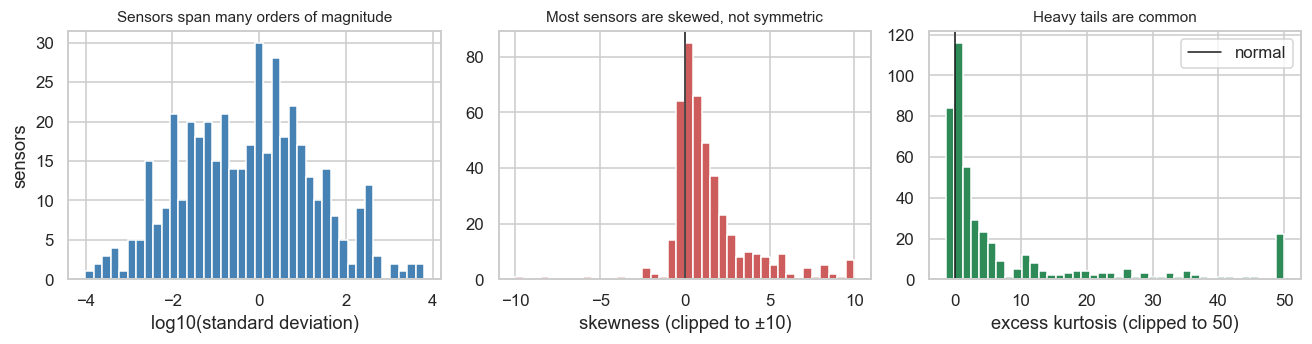

sensors with |skew| > 2      : 118 of 436
sensors with kurtosis > 10   : 96
std ranges from 9.84e-05 to 6.32e+03


In [4]:
# How are the sensors distributed in shape and scale?
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

ax[0].hist(np.log10(prof["std"].replace(0, np.nan).dropna()), bins=40, color="steelblue")
ax[0].set_xlabel("log10(standard deviation)"); ax[0].set_ylabel("sensors")
ax[0].set_title("Sensors span many orders of magnitude")

ax[1].hist(prof["skew"].clip(-10, 10), bins=40, color="indianred")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("skewness (clipped to ±10)")
ax[1].set_title("Most sensors are skewed, not symmetric")

ax[2].hist(prof["kurtosis"].clip(-5, 50), bins=40, color="seagreen")
ax[2].axvline(0, color="k", lw=1, label="normal")
ax[2].set_xlabel("excess kurtosis (clipped to 50)")
ax[2].set_title("Heavy tails are common"); ax[2].legend()
plt.tight_layout(); plt.show()

print(f"sensors with |skew| > 2      : {(prof['skew'].abs() > 2).sum()} of {len(prof)}")
print(f"sensors with kurtosis > 10   : {(prof['kurtosis'] > 10).sum()}")
print(f"std ranges from {prof['std'].min():.2e} to {prof['std'].max():.2e}")

**Three findings that shape everything downstream.**

The standard deviations span many orders of magnitude — these are physically different quantities
(pressures, temperatures, counts, times) recorded in their native units. Any distance-based or
gradient-based model will be dominated by the large-scale sensors unless the data is standardised.
That confirms scaling is required, and it belongs in the modelling pipeline where it can be fitted
per fold.

Most sensors are skewed rather than symmetric, and many have heavy tails even after the winsorization
applied during wrangling. This matters for test selection in §3: a t-test assumes approximate
normality of the sampling distribution, so a rank-based test is needed as a cross-check.

A number of sensors have very few distinct values — effectively discrete or quantised readings —
which is worth remembering before treating everything as continuous.

In [5]:
# Normality check on a random sample of sensors (Shapiro-Wilk)
rng = np.random.default_rng(42)
sample = rng.choice(SENSORS, size=60, replace=False)
sw = pd.Series({s: stats.shapiro(train[s].sample(500, random_state=0))[1] for s in sample})

print(f"Shapiro-Wilk on 60 randomly chosen sensors:")
print(f"  reject normality at p < 0.05 : {(sw < 0.05).sum()} of {len(sw)}")
print(f"  median p-value               : {sw.median():.2e}")
print("\n=> normality cannot be assumed; §3 reports a rank-based test alongside the t-test.")

Shapiro-Wilk on 60 randomly chosen sensors:
  reject normality at p < 0.05 : 57 of 60
  median p-value               : 6.36e-18

=> normality cannot be assumed; §3 reports a rank-based test alongside the t-test.


---
### 2.1 The response variable

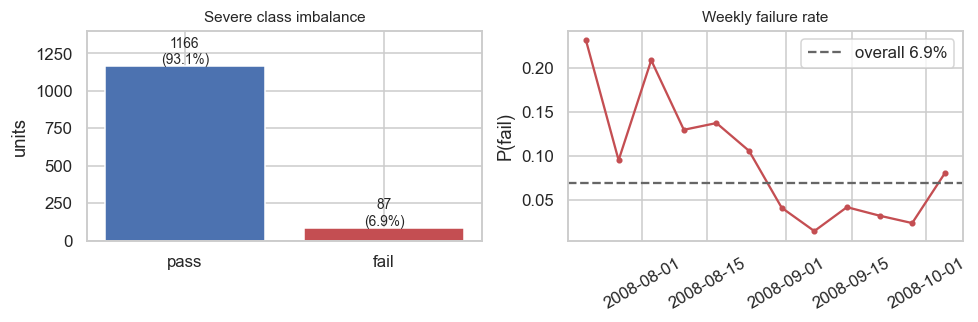

imbalance ratio: 13.4 passes per failure


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
counts = y.value_counts().sort_index()
ax[0].bar(["pass", "fail"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 15, f"{v}\n({v/len(y):.1%})", ha="center", fontsize=9)
ax[0].set_ylabel("units"); ax[0].set_title("Severe class imbalance")
ax[0].set_ylim(0, counts.max() * 1.2)

monthly = train.set_index("timestamp").resample("W")["fail"].mean()
ax[1].plot(monthly.index, monthly.values, marker="o", ms=3, color="#C44E52")
ax[1].axhline(y.mean(), ls="--", color="0.4", label=f"overall {y.mean():.1%}")
ax[1].set_title("Weekly failure rate"); ax[1].set_ylabel("P(fail)")
ax[1].tick_params(axis="x", rotation=30); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"imbalance ratio: {(1-y).sum() / y.sum():.1f} passes per failure")

In [7]:
cou

NameError: name 'cou' is not defined

The imbalance is the single most important characteristic of this dataset. Three consequences:

- **Accuracy is a useless metric.** Predicting "pass" for every unit scores 93.1%.
- **Precision, recall, and PR-AUC** are the metrics that mean something here. ROC-AUC is optimistic
  under heavy imbalance because the large negative class makes the false-positive rate move slowly.
- **Statistical power is limited by the 87 failures**, not by the 1,253 units. Every test below is
  effectively a small-sample test.

---
## 3. Inferential statistics — which sensors separate pass from fail?

**Hypotheses.** For each sensor $j$:

> $H_0$: the distribution of sensor $j$ is the same for failing and passing units.
> $H_1$: the distributions differ.

**Tests used, and why two.** Welch's t-test compares means without assuming equal variances — the
right choice given that the two groups differ enormously in size. But §2 showed the sensors are
skewed and heavy-tailed, so the Mann-Whitney U test is run alongside it. It compares distributions
by rank, needs no distributional assumption, and is far less influenced by extreme values. Where the
two agree, the finding is solid; where they disagree, the difference is being driven by tails rather
than by a genuine shift in the bulk of the distribution.

**Multiple comparisons.** Testing 436 sensors at α = 0.05 would yield roughly 22 false positives
even if no sensor mattered at all. Benjamini–Hochberg FDR control is applied so that the reported
discoveries have a controlled expected false-discovery proportion. BH is used rather than Bonferroni
because the goal here is a candidate list for modelling, not a definitive claim about each sensor —
FDR keeps power up.

**Effect size.** A p-value only says whether a difference is detectable; it says nothing about
whether the difference is large enough to be useful. Cohen's *d* is reported for each sensor, plus
the point-biserial correlation with the label.

In [ ]:
def bh_fdr(p):
    # Benjamini-Hochberg adjusted p-values
    p = np.asarray(p, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    adj[order] = np.minimum.accumulate((p[order] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(adj, 0, 1)

fail_mask = y == 1
rows = []
for s in SENSORS:
    a, b = train.loc[fail_mask, s], train.loc[~fail_mask, s]
    if a.nunique() <= 1 and b.nunique() <= 1:
        continue
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    # Cohen's d with pooled SD
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    d = (a.mean() - b.mean()) / sp if sp > 0 else 0.0
    r_pb, r_p = stats.pointbiserialr(y, train[s])
    rows.append({"sensor": s, "mean_fail": a.mean(), "mean_pass": b.mean(),
                 "cohens_d": d, "t_p": t_p, "mw_p": u_p, "r_pb": r_pb})

tests = pd.DataFrame(rows)
tests["t_p_fdr"]  = bh_fdr(tests.t_p)
tests["mw_p_fdr"] = bh_fdr(tests.mw_p)
tests["abs_d"] = tests.cohens_d.abs()
tests = tests.sort_values("t_p_fdr").reset_index(drop=True)

print(f"sensors tested                          : {len(tests)}")
print(f"significant, Welch t-test  (FDR < 0.05) : {(tests.t_p_fdr < ALPHA).sum()}")
print(f"significant, Mann-Whitney  (FDR < 0.05) : {(tests.mw_p_fdr < ALPHA).sum()}")
print(f"significant on BOTH tests               : {((tests.t_p_fdr < ALPHA) & (tests.mw_p_fdr < ALPHA)).sum()}")
print(f"\nuncorrected p < 0.05 (for contrast)     : {(tests.t_p < ALPHA).sum()}"
      f"   <- ~{int(0.05*len(tests))} expected by chance alone")

In [ ]:
sig = tests[(tests.t_p_fdr < ALPHA) | (tests.mw_p_fdr < ALPHA)].copy()
print(f"Sensors significant on at least one test: {len(sig)}\n")
display(sig.head(15)[["sensor", "mean_fail", "mean_pass", "cohens_d", "r_pb",
                      "t_p_fdr", "mw_p_fdr"]].round(4))

In [ ]:
# Where do the effect sizes sit? Cohen's conventions: 0.2 small, 0.5 medium, 0.8 large.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

ax[0].hist(tests.abs_d, bins=50, color="steelblue")
for v, lab in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    ax[0].axvline(v, ls="--", lw=1, color="crimson")
    ax[0].text(v, ax[0].get_ylim()[1]*0.9, lab, rotation=90, fontsize=7, ha="right")
ax[0].set_xlabel("|Cohen's d|"); ax[0].set_ylabel("sensors")
ax[0].set_title("Effect sizes are small across the board")

# Volcano plot: effect size against significance
ax[1].scatter(tests.cohens_d, -np.log10(tests.t_p), s=8, alpha=0.4, color="0.5")
hit = tests.t_p_fdr < ALPHA
ax[1].scatter(tests.cohens_d[hit], -np.log10(tests.t_p[hit]), s=18, color="crimson",
              label=f"FDR < {ALPHA} (n={hit.sum()})")
ax[1].set_xlabel("Cohen's d  (fail − pass)"); ax[1].set_ylabel("−log10(p)")
ax[1].set_title("Volcano plot"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"largest |d| : {tests.abs_d.max():.3f}  ({tests.loc[tests.abs_d.idxmax(), 'sensor']})")
print(f"median |d|  : {tests.abs_d.median():.3f}")
print(f"sensors with |d| > 0.5 : {(tests.abs_d > 0.5).sum()}")

**This is the central result of the EDA.**

A handful of sensors do reach a respectable effect size — the strongest is close to Cohen's "large"
threshold, and seven exceed the "medium" mark. But the median effect across all 436 sensors is near
zero, and only a small minority survive FDR correction at all. **No single sensor comes close to
separating failing from passing units on its own.** If one did, this problem would be solved with a
control chart and would not need machine learning.

The practical implication: a workable model has to pool weak signals across many sensors rather than
lean on a few strong ones. That points toward regularised linear models and tree ensembles, and away
from expecting a simple interpretable rule. It also sets a realistic performance expectation — a
model that catches even a modest share of failures at usable precision is valuable on a line where
each missed failure is a scrapped unit.

The volcano plot makes the multiple-comparisons problem concrete. Far more sensors clear an
uncorrected p < 0.05 than survive FDR correction, and the uncorrected count is close to what pure
chance would produce across 436 tests. Reporting that number would have been a serious overstatement.

---
### 3.1 Do the missing-value indicators carry signal?

In [ ]:
# Chi-square test: is a sensor being offline associated with failure?
flag_rows = []
for f in FLAGS:
    tab = pd.crosstab(train[f], y)
    if tab.shape == (2, 2) and tab.values.min() >= 1:
        chi2, p, _, _ = stats.chi2_contingency(tab)
        rate_missing = y[train[f] == 1].mean()
        rate_present = y[train[f] == 0].mean()
        flag_rows.append({"flag": f, "n_missing": int(train[f].sum()),
                          "fail_rate_missing": rate_missing,
                          "fail_rate_present": rate_present,
                          "lift": rate_missing / rate_present if rate_present else np.nan,
                          "p": p})

flags_df = pd.DataFrame(flag_rows).sort_values("p")
if len(flags_df):
    flags_df["p_fdr"] = bh_fdr(flags_df.p)
    n_sig = (flags_df.p_fdr < ALPHA).sum()
    print(f"missing-indicators tested: {len(flags_df)}  |  significant (FDR < {ALPHA}): {n_sig}\n")
    display(flags_df.head(8).round(4))

This is why the wrangling notebook kept the indicators rather than imputing silently. Where a flag is
significant, the *fact that a sensor went offline* is associated with the unit failing — plausibly
because the same tool fault that stops a measurement also degrades the process. That information
would have been destroyed by imputation alone.

---
## 4. Data visualisation — what do the relationships look like?

Numbers established *which* sensors differ. Plots establish *how*, and guard against being misled:
a significant t-test can be produced by three outliers, by a bimodal split, or by a genuine shift,
and only a plot tells them apart.

In [ ]:
top6 = tests.nsmallest(6, "t_p_fdr").sensor.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, s in zip(axes.ravel(), top6):
    for lab, colour in [(0, "#4C72B0"), (1, "#C44E52")]:
        sns.kdeplot(train.loc[y == lab, s], ax=ax, fill=True, alpha=0.35,
                    color=colour, label="fail" if lab else "pass", lw=1.2)
    r = tests.loc[tests.sensor == s].iloc[0]
    ax.set_title(f"{s}   d={r.cohens_d:+.2f},  FDR p={r.t_p_fdr:.3f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Distribution by outcome — the six most significant sensors", y=1.01)
plt.tight_layout(); plt.show()

The overlap between the two curves is the story. Even for the most significant sensors the
distributions sit almost on top of each other, with only a modest shift in centre or spread. This is
the visual counterpart of the small effect sizes — and it is why a threshold rule on any single
sensor would misclassify heavily.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, s in zip(axes, top6[:4]):
    sns.boxplot(x=y.map({0: "pass", 1: "fail"}), y=train[s], ax=ax,
                palette=["#4C72B0", "#C44E52"], width=0.55, fliersize=2)
    ax.set_title(s, fontsize=9); ax.set_xlabel("")
plt.suptitle("Same sensors as box plots — median shift and spread", y=1.03)
plt.tight_layout(); plt.show()

In [ ]:
# Bi-plot: do two weak sensors separate the classes better together than alone?
s1, s2 = top6[0], top6[1]
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(train.loc[y == 0, s1], train.loc[y == 0, s2], s=10, alpha=0.35,
           color="#4C72B0", label="pass")
ax.scatter(train.loc[y == 1, s1], train.loc[y == 1, s2], s=22, alpha=0.85,
           color="#C44E52", edgecolor="k", linewidth=0.3, label="fail")
ax.set_xlabel(s1); ax.set_ylabel(s2)
ax.set_title(f"Joint distribution: {s1} vs {s2}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Failures are scattered through the passing cloud rather than occupying a distinct region -")
print("no two-sensor rule will separate them. A model needs many features at once.")

---
## 5. Correlation structure among the sensors

In [ ]:
corr = train[SENSORS].corr()
corr.head()

In [ ]:
corr = train[SENSORS].corr()
abs_corr = corr.abs().mask(np.eye(len(SENSORS), dtype=bool))   # blank the diagonal

pairs = (abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
                 .stack().sort_values(ascending=False))

print("Pairwise |Pearson r| among 436 sensors")
print(f"  pairs                : {len(pairs):,}")
print(f"  median |r|           : {pairs.median():.3f}")
for t in [0.7, 0.8, 0.9, 0.95]:
    print(f"  pairs with |r| > {t}  : {(pairs > t).sum():,}")
print(f"\nsensors with at least one partner above 0.9: "
      f"{(abs_corr.max() > 0.9).sum()} of {len(SENSORS)}")
print("\nStrongest pairs:")
display(pairs.head(8).to_frame("abs_r").round(4))

In [ ]:
# Cluster the 60 most variable sensors to show the block structure
top_var = prof.nlargest(60, "cv").index.tolist()
sub = train[top_var].corr()

g = sns.clustermap(sub, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                   figsize=(8.5, 8), xticklabels=False, yticklabels=False,
                   cbar_pos=(0.02, 0.83, 0.03, 0.12))
g.figure.suptitle("Correlation among 60 high-variability sensors (clustered)", y=1.0, fontsize=10)
plt.show()

**The correlation structure is local, not global.** The median pairwise correlation is essentially
zero — most sensor pairs are unrelated, as you would expect from measurements taken at different
stages of a long process. But roughly two-thirds of sensors have at least one partner correlated
above 0.9, and the clustermap shows why: the redundancy is concentrated in tight blocks, almost
certainly measurements from the same tool, chamber, or process step.

That pattern has three consequences:

- **Linear models will be unstable.** Within a block, correlated predictors split coefficient weight
  arbitrarily between themselves, so signs and magnitudes cannot be read directly. L2 or elastic-net
  regularisation handles this; plain logistic regression does not.
- **Tree-based importance will be diluted.** Where five sensors carry the same information, each
  receives a fraction of the importance, and all five can look unimportant.
- **The effective dimensionality is well below 436.** Encouraging, given only 87 failures — the model
  does not need to learn 436 independent relationships.

---
## 6. Temporal structure

The proposal frames this as a time-series problem, so two questions matter that a standard EDA would
skip: do the sensors drift over the collection window, and are failures clustered in time?

Both bear directly on deployment. A model trained on July data that is scored on October data will
degrade if the sensors have drifted, and that degradation is invisible to a randomly-split
validation.

In [ ]:
# Split the training window in half and test each sensor for a shift between halves.
half = len(train) // 2
early, late = train.iloc[:half], train.iloc[half:]

drift = []
for s in SENSORS:
    _, p = stats.ks_2samp(early[s], late[s])
    sd = train[s].std()
    shift = (late[s].mean() - early[s].mean()) / sd if sd > 0 else 0.0
    drift.append({"sensor": s, "ks_p": p, "shift_in_sd": shift})

drift = pd.DataFrame(drift)
drift["ks_p_fdr"] = bh_fdr(drift.ks_p)
drift["abs_shift"] = drift.shift_in_sd.abs()
n_drift = (drift.ks_p_fdr < ALPHA).sum()

print(f"Kolmogorov-Smirnov, first half vs second half of the training window")
print(f"  sensors with significant drift (FDR < {ALPHA}) : {n_drift} of {len(drift)} "
      f"({n_drift/len(drift):.0%})")
print(f"  sensors shifted by more than 0.5 SD          : {(drift.abs_shift > 0.5).sum()}")
display(drift.nlargest(6, "abs_shift")[["sensor", "shift_in_sd", "ks_p_fdr"]].round(4))

In [ ]:
worst_drift = drift.nlargest(3, "abs_shift").sensor.tolist()
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, s in zip(axes, worst_drift):
    roll = train.set_index("timestamp")[s].rolling(50, min_periods=10).mean()
    ax.plot(train.timestamp, train[s], lw=0.4, alpha=0.3, color="0.6")
    ax.plot(roll.index, roll.values, lw=1.6, color="crimson")
    ax.set_title(f"{s}  (shift {drift.loc[drift.sensor==s,'shift_in_sd'].iloc[0]:+.2f} SD)",
                 fontsize=9)
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("reading")
plt.suptitle("Sensors with the largest drift (50-unit rolling mean in red)", y=1.03)
plt.tight_layout(); plt.show()

In [ ]:
# Are failures clustered in time, or spread evenly?
gaps = np.diff(np.where(y.values == 1)[0])
print(f"failures: {y.sum()} over {len(train)} units")
print(f"gap between consecutive failures - mean {gaps.mean():.1f}, median {np.median(gaps):.0f}, "
      f"min {gaps.min()}, max {gaps.max()} units")

# Under a random arrangement, gaps would be roughly geometric with this mean.
# A high variance-to-mean ratio indicates clustering.
vmr = gaps.var() / gaps.mean()
print(f"variance-to-mean ratio of gaps: {vmr:.2f}   (1.0 ~ random, >1 suggests clustering)")

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.vlines(train.timestamp[y == 1], 0, 1, color="crimson", lw=0.8, alpha=0.8)
ax.set_yticks([]); ax.set_title("When failures occurred", fontsize=10)
ax.set_xlim(train.timestamp.min(), train.timestamp.max())
plt.tight_layout(); plt.show()

Both results feed directly into the modelling design, and the drift result is stronger than expected.

**Drift is pervasive.** The large majority of sensors show a statistically detectable distribution
shift between the first and second half of a three-month window, and several dozen move by more than
half a standard deviation. Some of this is the KS test's sensitivity at n ≈ 600 per half — it will
flag shifts too small to matter — which is why the shift-in-SD column is reported alongside it. But
the direction is unambiguous: this process does not sit still.

That makes time-ordered validation mandatory rather than merely preferable, argues for periodic
retraining in deployment, and turns the largest-drifting sensors into natural candidates for a
monitoring dashboard.

**Failures cluster.** The gaps between consecutive failures are far more variable than a random
arrangement would produce, so failures arrive in bursts rather than independently. If the last few
units failed, the next one is more likely to. That justifies the lag and rolling features engineered
in §7 — features a standard i.i.d. tabular model would never see.

---
## 7. Feature selection and engineering

Selection here means producing a **ranked candidate list**, not a final feature set. The actual
selection must happen inside the cross-validation loop, because choosing features using the labels
of all 1,253 training units and then cross-validating on those same units gives an optimistic score.
What is built below is the ranking and the engineered columns; the cut-off is a modelling decision.

### 7.1 Ranking the existing features

In [ ]:
ranking = tests[["sensor", "abs_d", "r_pb", "t_p_fdr", "mw_p_fdr"]].copy()
ranking["neg_log_p"] = -np.log10(tests.t_p.clip(lower=1e-300))

# Combine three views: effect size, correlation with the label, and significance.
for col in ["abs_d", "neg_log_p"]:
    ranking[f"{col}_rank"] = ranking[col].rank(ascending=False)
ranking["r_pb_rank"] = ranking.r_pb.abs().rank(ascending=False)
ranking["score"] = ranking[["abs_d_rank", "neg_log_p_rank", "r_pb_rank"]].mean(axis=1)
ranking = ranking.sort_values("score").reset_index(drop=True)

print("Top 15 candidate sensors (consensus of effect size, correlation, and significance)\n")
display(ranking.head(15)[["sensor", "abs_d", "r_pb", "t_p_fdr", "score"]].round(4))
ranking.to_csv(OUT / "eda_feature_ranking.csv", index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
top20 = ranking.head(20).iloc[::-1]
colours = ["#C44E52" if v > 0 else "#4C72B0" for v in
           tests.set_index("sensor").loc[top20.sensor, "cohens_d"]]
ax.barh(top20.sensor, tests.set_index("sensor").loc[top20.sensor, "cohens_d"], color=colours)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Cohen's d   (negative = lower in failures)")
ax.set_title("Top 20 candidate sensors by consensus rank")
plt.tight_layout(); plt.show()

### 7.2 Engineering new features

In [ ]:
eng = train[["timestamp", "fail"]].copy()

# (a) Aggregate anomaly features - how unusual is this unit overall?
med = train[SENSORS].median()
mad = (train[SENSORS] - med).abs().median() * 1.4826
rz = ((train[SENSORS] - med) / mad.replace(0, np.nan)).abs()

eng["n_extreme"]   = (rz > 3).sum(axis=1)          # count of unusual readings
eng["max_z"]       = rz.max(axis=1)                # most unusual single reading
eng["mean_z"]      = rz.mean(axis=1)               # overall unusualness
eng["n_missing"]   = train[FLAGS].sum(axis=1)      # sensors offline for this unit

# (b) Temporal features - recent process history
eng["hour"]        = train.timestamp.dt.hour
eng["units_1h"]    = (train.set_index("timestamp").assign(one=1)
                        .rolling("1h")["one"].sum().values)   # throughput
eng["prev_gap_min"] = train.timestamp.diff().dt.total_seconds().div(60).fillna(0)

# (c) Block summaries - collapse correlated groups into means
q = len(SENSORS) // 4
for i in range(4):
    block = SENSORS[i*q:(i+1)*q]
    zblock = (train[block] - train[block].mean()) / train[block].std().replace(0, np.nan)
    eng[f"block{i}_mean_z"] = zblock.mean(axis=1)

new_feats = [c for c in eng.columns if c not in ("timestamp", "fail")]
print(f"engineered features: {len(new_feats)}")
eng[new_feats].describe().T.round(3)

In [ ]:
# Do any of the engineered features beat the raw sensors?
eng_rows = []
for f in new_feats:
    a, b = eng.loc[fail_mask, f], eng.loc[~fail_mask, f]
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    eng_rows.append({"feature": f, "mean_fail": a.mean(), "mean_pass": b.mean(),
                     "cohens_d": (a.mean()-b.mean())/sp if sp > 0 else 0, "p": p})

eng_tests = pd.DataFrame(eng_rows).sort_values("p")
eng_tests["p_fdr"] = bh_fdr(eng_tests.p)
display(eng_tests.round(4))

best_raw = tests.abs_d.max()
best_eng = eng_tests.cohens_d.abs().max()
print(f"\nbest raw sensor |d|      : {best_raw:.3f}")
print(f"best engineered |d|      : {best_eng:.3f}")
print("engineered features worth keeping:",
      eng_tests.loc[eng_tests.p_fdr < ALPHA, "feature"].tolist() or "none reach FDR significance")

In [ ]:
sig_eng = eng_tests[eng_tests.p_fdr < ALPHA].feature.tolist()
show = (sig_eng + eng_tests.feature.tolist())[:3]
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, f in zip(axes, show):
    sns.boxplot(x=eng.fail.map({0: "pass", 1: "fail"}), y=eng[f], ax=ax,
                palette=["#4C72B0", "#C44E52"], width=0.55, fliersize=2)
    d = eng_tests.loc[eng_tests.feature == f, "cohens_d"].iloc[0]
    ax.set_title(f"{f}   d={d:+.2f}", fontsize=9); ax.set_xlabel("")
plt.suptitle("Engineered features by outcome", y=1.03)
plt.tight_layout(); plt.show()

In [ ]:
# Save the EDA-enriched training features for the modelling notebook
enriched = pd.concat([train, eng[new_feats]], axis=1)
enriched.to_csv(OUT / "secom_train_eda.csv", index=False)
print(f"saved secom_train_eda.csv: {enriched.shape[0]:,} rows x {enriched.shape[1]} columns")
print(f"saved eda_feature_ranking.csv: ranking for all {len(ranking)} sensors")

---
## 8. Answering the guide's questions

**Are there variables that are particularly significant in terms of explaining the project question?**

A small number, yes — a handful of sensors survive FDR correction, and the strongest reaches an
effect size approaching Cohen's "large". But they are the exception. The median effect across all
436 sensors is near zero, the class distributions overlap heavily even for the top-ranked sensors,
and no single variable comes close to explaining failure on its own. The ranked list in §7.1 gives
modelling a starting point; the signal itself is distributed.

**Are there significant differences between subgroups?**

Yes, in two places. Units where a sensor went offline fail at a different rate than units where it
recorded (§3.1) — several missing-value indicators are significant, carrying information independent
of the readings themselves. And failures are not spread evenly through time (§6); they arrive in
bursts, which makes recent process history a subgroup signal in its own right.

**Are there strong correlations between pairs of independent variables, or with the dependent
variable?**

Between independent variables: locally, yes. Most pairs are uncorrelated, but around two-thirds of
sensors have at least one partner above |r| = 0.9, forming tight blocks that correspond to shared
tools or process stages. Between independent and dependent variables: no — point-biserial
correlations with the failure label are uniformly weak.

That asymmetry defines the dataset: **strong block-wise redundancy among predictors, weak correlation
with the target.** It rules out simple approaches and points toward regularised models that can pool
weak, redundant signals.

**What are the most appropriate tests?**

Welch's t-test for mean differences without assuming equal variances, Mann-Whitney U as a
distribution-free cross-check given the skew and non-normality documented in §2, chi-square for the
binary missing-indicators, Kolmogorov-Smirnov for temporal drift, and Benjamini-Hochberg FDR
correction throughout — without it, 436 simultaneous tests produce dozens of spurious findings, as
the gap between the corrected and uncorrected counts in §3 shows directly.

---
## 9. Summary and next steps

**What the data looks like.** 1,253 units, 436 sensors, 6.9% failure rate. Sensors are skewed,
heavy-tailed, non-normal, on wildly different scales, and organised into tight blocks of mutually
redundant measurements.

**What predicts failure.** Weakly, many things; strongly, almost nothing. A small set of sensors
survives FDR correction, with effect sizes ranging from negligible up to one approaching "large".
Several missing-value indicators add independent signal. Failures cluster in time, so recent history
is informative. Most sensors drift measurably across the three-month window.

**Decisions this supports for modelling.**

| Decision | Evidence |
|---|---|
| Scale features inside the pipeline | §2 — SDs span orders of magnitude |
| Use PR-AUC and recall, not accuracy | §2.1 — 93.1% accuracy from predicting "pass" always |
| Prefer regularised or ensemble models | §3, §5 — weak distributed signal, correlated predictors |
| Validate with time-ordered CV | §6 — significant sensor drift across the window |
| Keep the missing-value indicators | §3.1 — several are significantly associated with failure |
| Include lag/rolling features | §6 — failures arrive in bursts |
| Don't expect a simple interpretable rule | §4 — heavy class overlap in every bi-plot |

**Deliberately not done here.** Final feature selection, scaling, and class balancing all use the
labels or the full training distribution, so they belong inside the cross-validation loop rather than
in a saved dataset. The ranking produced in §7.1 is an input to that process, not a substitute for it.

**Next notebook.** Baseline models (logistic regression with class weights, random forest, gradient
boosting), time-ordered cross-validation, and threshold tuning against the cost of a missed failure
versus a false alarm.